<a href="https://colab.research.google.com/github/madebyann/colab/blob/main/Randomized_algorithm_max_cut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROBLEMA MAX-CUT**

Sia $G = (V,E)$ un grafo non orientato e siano assegnati pesi non negativi $w_{ij}=w_{ji}$ agli archi $\{i,j\} \in E$.
Il **problema del taglio massimo (MAX-CUT)** consiste nel determinare un sottoinsieme di vertici $S \subseteq V$ che massimizza $w(\delta(S))$, dove $\delta(S)=\{ \{u,v\} \in E : u \in S, v \in V \smallsetminus S\}$.

Vediamo un esempio:

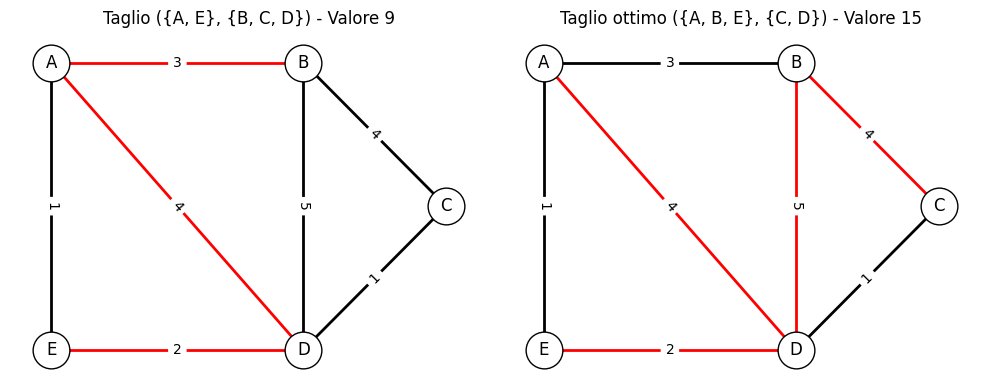

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Definizione del grafo
G = nx.Graph()
edges = [
    ('A', 'B', 3), ('B', 'C', 4), ('A', 'E', 1),
    ('E', 'D', 2), ('C', 'D', 1), ('A', 'D', 4), ('B', 'D', 5)
]
for u, v, w in edges:
    G.add_edge(u, v, weight=w)

pos = {'A': (0, 3), 'B': (3, 3), 'C': (4.7, 1.5), 'D': (3, 0), 'E': (0, 0)}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Taglio 1
cut1_red = [('A','B'), ('E','D'), ('A','D')]
colors1 = ['red' if (u,v) in cut1_red or (v,u) in cut1_red else 'black' for u,v in G.edges()]
nx.draw_networkx_nodes(G, pos, ax=axes[0], node_color='white', edgecolors='black', node_size=700)
nx.draw_networkx_labels(G, pos, ax=axes[0])
nx.draw_networkx_edges(G, pos, ax=axes[0], edge_color=colors1, width=2)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u,v): d['weight'] for u,v,d in G.edges(data=True)}, ax=axes[0])
axes[0].set_title("Taglio ({A, E}, {B, C, D}) - Valore 9")
axes[0].axis('off')

# Taglio 2 (Ottimo)
cut2_red = [('B','C'), ('E','D'), ('A','D'), ('B','D')]
colors2 = ['red' if (u,v) in cut2_red or (v,u) in cut2_red else 'black' for u,v in G.edges()]
nx.draw_networkx_nodes(G, pos, ax=axes[1], node_color='white', edgecolors='black', node_size=700)
nx.draw_networkx_labels(G, pos, ax=axes[1])
nx.draw_networkx_edges(G, pos, ax=axes[1], edge_color=colors2, width=2)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u,v): d['weight'] for u,v,d in G.edges(data=True)}, ax=axes[1])
axes[1].set_title("Taglio massimo ({A, B, E}, {C, D}) - Valore 15")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Ora per semplicità useremo i numeri al posto delle lettere per i vertici.

# **Algoritmo randomizzato per MAX-CUT**

**INPUT** Un grafo non orientato $G=(V,E)$ con pesi $(w_{ij})_{\{i,j\} \in E}$.

**OUTPUT** Una partizione $(S, V \smallsetminus S)$ e il valore del taglio $SOL$.

1.   **ASSEGNAZIONE CASUALE**: per ogni vertice $v \in V$, si assegni $v$ all'insieme $S$ o $V \smallsetminus S$ con probabilità $1/2$.
    
2.   **CALCOLO DEL TAGLIO**: si ponga $SOL = \sum_{\substack{\{i,j\}\in E \\ i\in S, j \notin S}} w_{ij}$
    
3.   **CONCLUSIONE**: si restituisca la partizione $(S, V \smallsetminus S)$ e il valore del taglio $SOL$.

Implementiamo l'algoritmo e proviamolo sul grafo dell'esempio precedente: osserviamo che ripetendo il codice il risultato cambia.

In [ ]:
import random
def rand_max_cut(n,edges,weights):
  SOL = 0
  S = set()
  V_minus_S = set()
  # assegnazione casuale (da 1 a n)
  for i in range(1,n+1):
    if random.random() < 0.5:
      S.add(i)
    else:
      V_minus_S.add(i)

  # scorriamo gli archi per calcolarne il taglio
  for (u,v) in edges:
    if (u in S and v in V_minus_S) or (u in V_minus_S and v in S):
      # Gestisci sia (u,v) che (v,u) come chiavi possibili per il peso
      if (u,v) in weights:
        SOL += weights[(u,v)]
      elif (v,u) in weights:
        SOL += weights[(v,u)]
  return S, V_minus_S, SOL

# consideriamo il grafo con 5 vertici
n = 5

# con i seguenti archi
edges = [(1,2), (1,4), (1,5), (2,3), (2,4), (3,4), (4,5)]

# con i seguenti pesi
weights = {(1,2):3, (1,4):4, (1,5):1, (2,3):4, (2,4):5, (3,4):1, (4,5):2}

print(rand_max_cut(n,edges,weights))

({3, 5}, {1, 2, 4}, 8)


# **Algoritmo di Sahni e Gonzalez per MAX-CUT**

L’algoritmo $k$-MAX-CUT deterministico nel caso di $k=2$ prevede che, dato il grafo non orientato $G=(V,E)$ con $V=\{1,\dots,n\}$, i vertici $1$ e $2$ vengano inseriti rispettivamente in $S$ e in $V \smallsetminus S$, e i rimanenti $n-2$ vertici vengano esaminati uno alla volta.

In particolare, per l'esecuzione dell'algoritmo introduciamo le seguenti variabili:

* **$SOL$**: il valore corrente del taglio.
* **$SET$**: vettore di dimensione $n$ usato come indicatore di appartenenza, definito nel modo seguente: per ogni vertice $i \in V$, $SET(i) \in \{1,2\}$ indica a quale dei due insiemi della partizione $(S, V \smallsetminus S)$ è assegnato il vertice $i$. Quando un vertice $i$ non è ancora stato assegnato, poniamo $SET(i)=0$.
* **$WT$**: vettore di dimensione $2$ usato come variabile di supporto: per il vertice $j$ analizzato in ogni iterazione, $WT(1)$ e $WT(2)$ memorizzano la somma dei pesi degli archi che collegano $j$ ai vertici già assegnati rispettivamente agli insiemi $S$ e $V \smallsetminus S$.

---

### **Struttura dell'Algoritmo**

**INPUT:** Un grafo non orientato $G=(V,E)$ con $V=\{1,\dots,n\}$ e pesi $w_{ij} \ge 0$ per ogni $\{i,j\} \in E$.  
**OUTPUT:** Una partizione $(S, V \smallsetminus S)$ e il valore del taglio $SOL$.

1. **INIZIALIZZAZIONE**
   1.1. Se $n \le 2$:
   * Si pongano $SET(i) \gets i$ per ogni $i \in V$
   * Si ponga $SOL \gets \sum_{\{i,j\} \in E} w_{ij}$
   * Si restituisca la partizione $(S, V \smallsetminus S)$ con $S = \{i \in V : SET(i) = 1\}$ e **STOP**.

   1.2. Altrimenti ($n > 2$):
   * Si pongano $WT(1) \gets 0$ e $WT(2) \gets 0$
   * Si pongano $SET(1) \gets 1$, $SET(2) \gets 2$ e $SET(i) \gets 0$ per $i = 3, \dots, n$
   * Si ponga $SOL \gets w_{12}$ (se $\{1,2\} \in E$, altrimenti $0$)

2. **FASE ITERATIVA**  
   Per ogni vertice $j = 3, \dots, n$:
   
   2.1. Per ogni arco $\{j,m\} \in E$: se $SET(m) \neq 0$, si aggiorni:
   $$WT(SET(m)) \gets WT(SET(m)) + w_{jm}$$

   2.2. Si scelga $z \in \{1,2\}$ in modo da assegnare $j$ all'insieme opposto a quello verso cui ha più peso (ossia massimizzando il taglio verso il secondo insieme):
   $$z \gets \begin{cases} 2 & \text{se } WT(1) \ge WT(2) \\ 1 & \text{se } WT(1) < WT(2) \end{cases}$$

   2.3. Si aggiorni l'appartenenza del vertice:
   $$SET(j) \gets z$$

   2.4. Per ogni arco $\{j,m\} \in E$: se $SET(m) \neq 0$ e $SET(m) \neq SET(j)$, si aggiorni il valore del taglio:
   $$SOL \gets SOL + w_{jm}$$

   2.5. Si resettino i pesi locali per l'iterazione successiva:
   $$WT(1) \gets 0, \quad WT(2) \gets 0$$

---

### **CONCLUSIONE**
Si restituisca la partizione $(S, V \smallsetminus S)$ con $S = \{i \in V : SET(i) = 1\}$ e il valore finale del taglio $SOL$.

Implementiamo l'algoritmo e testiamolo sul grafo di esempio

In [ ]:
def sahni_gonzalez_max_cut(n, edges, weights):
    # Lista di adiacenza per vertici
    adj = [[] for _ in range(n)]
    for u, v in edges:
        w = weights[(u, v)] if (u, v) in weights else weights[(v, u)]
        adj[u - 1].append((v - 1, w))
        adj[v - 1].append((u - 1, w))

    SET = [0] * n
    SOL = 0

    # Inizializzazione (1.1)
    if n <= 2:
        for i in range(1, n + 1):
            SET[i - 1] = i
        SOL = sum(weights.values())

        S = [i for i in range(1, n + 1) if SET[i - 1] == 1]
        V_minus_S = [i for i in range(1, n + 1) if SET[i - 1] == 2]
        return S, V_minus_S, SOL

    # Inizializzazione (1.2)
    else:
        WT = [0, 0]
        SET[0] = 1
        SET[1] = 2

        # Cerca l'arco {1, 2}
        for vicino, peso in adj[0]:
            if vicino == 1:
                SOL = peso
                break

        # Fase iterativa
        for j in range(2, n):
            # 2.1
            for m, peso in adj[j]:
                if SET[m] != 0:
                    WT[SET[m] - 1] += peso

            # 2.2 e 2.3
            if WT[0] <= WT[1]:
                SET[j] = 1
            else:
                SET[j] = 2

            # 2.4
            for m, peso in adj[j]:
                if SET[m] != 0 and SET[m] != SET[j]:
                    SOL += peso

            # 2.5
            WT = [0, 0]

    # 3: Conclusione
    S = [i for i in range(1, n + 1) if SET[i - 1] == 1]
    V_minus_S = [i for i in range(1, n + 1) if SET[i - 1] == 2]
    return S, V_minus_S, SOL

print(sahni_gonzalez_max_cut(n,edges,weights))

([1, 3, 4], [2, 5], 15)


Osserviamo che il taglio ottenuto coincide con il taglio massimo. Questo è un caso: i due algoritmi precedenti garantiscono un'approssimazione di 1/2 del taglio massimo. Vediamo ora un algoritmo che garantisce un'approssimazione dell'87%.

# **Algoritmo di Goemans-Williamson per MAX-CUT**

**INPUT:** Un grafo non orientato $G=(V,E)$ con pesi $(w_{ij})_{\{i,j\} \in E}$.

**OUTPUT** Una partizione $(S, V \smallsetminus S)$ e il valore del taglio $W$.


1.   Si risolva il problema $$
\begin{aligned}
\max \quad & \sum_{i<j} w_{ij} \frac{1 - u_i \cdot u_j}{2} \\
\text{soggetto a} \quad & u_i \in S^{n-1} \qquad \forall i \in V
\end{aligned}
$$ ottenendo un insieme ottimo di vettori $u_i$

2.   Sia $r$ un vettore uniformemente distribuito sulla sfera unitaria $S^{n-1}$
    
3.   Si ponga $S = \{ i \mid u_i \cdot r \ge 0 \}$

4.   Si restituiscano la partizione $(S,V\smallsetminus S)$ e il valore del taglio $W=w(\delta(S))$

